:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_07_behavioral_states.ipynb`**!

:::


# Infer behavioral strategies during decision making with GLM-HMMs
One can think of decision-making as a stable process: given the same stimulus, an animal could be assumed to respond according to a fixed strategy with some added noise. However, growing evidence suggests that behavior is not stationary. Instead, animals fluctuate between distinct internal states that can persist over many trials. Traditional models, such as the classic lapse model, capture errors as random, independent events, but fail to account for these structured, state-dependent fluctuations in behavior. This raises the question: how can we infer these latent behavioral strategies directly from observed choices?

In this notebook, we address this question using the GLM-HMM framework, which combines a Generalized Linear Model (GLM; in particular, a Bernoulli GLM) with a Hidden Markov Model (HMM) to capture both how decisions change as a function of stimuli and how strategies evolve over time. We will show how to use choice data to recover hidden behavioral states using the NeMoS implementation of a Bernoulli GLM-HMM, replicating the main findings of Ashwood et al. (2022) <span id="cite1a"></span><a href="#ref1a">[1a]</a>.

Importantly, throughout the notebook we will assume you already have a solid theoretical understanding of GLMs and GLM-HMMs.

In [1]:
import os
import warnings

# On a cold cache, ONE downloads the dataset with a tqdm progress bar written to
# stderr. Its S3 downloader ignores ONE's `silent` flag, so disable tqdm itself.
# This has to happen before the bar is created, hence before the ONE import.
os.environ["TQDM_DISABLE"] = "1"

# The helper functions live in nemos's documentation utilities, which warn on
# import that they are not part of the public API; silence that here.
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# ONE issues an un-awaited-coroutine warning when streaming data; silence it.
warnings.filterwarnings(
    "ignore",
    message="coroutine .* was never awaited",
    category=RuntimeWarning,
)

# ONE warns that the aggregate table has no default revision when it downloads
# it for the first time; silence it.
warnings.filterwarnings(
    "ignore",
    message="No default revision for dataset.*",
)

In [2]:
# Imports
import nemos as nmo
import jax
import numpy as np
import seaborn as sns
from one.api import ONE
import matplotlib.pyplot as plt

# Helper functions for this tutorial
from nemos import _documentation_utils as tutorial_utils

In [3]:
# Enable 64-bit floating-point precision. Many quantities in a GLM-HMM are
# computed repeatedly and can be very small, so float64 guards against
# numerical errors accumulating.
jax.config.update("jax_enable_x64", True)

# Parameters for plotting
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

## Introduction

### The dataset

We will analyze the IBL decision-making task (IBL et al., 2021) <span id="cite2a"></span><a href="#ref2a">[2a]</a>, which is a variation of the two-alternative forced-choice perceptual detection task (Burgess et al., 2017) <span id="cite3"></span><a href="#ref3">[3]</a>. During this task, a sinusoidal grating with varying contrast [0\%-100\%] appeared either at the right or left side of the screen. The goal for the mice was to indicate this side by turning a little wheel so that this turn would accordingly move the stimuli to the center of the screen (Burgess et al., 2017) <span id="cite3"></span><a href="#ref3">[3]</a>. If the mice chose the side correctly, they would receive a water reward; if not, they would get a noise burst and a 1-second timeout. For the first 90 trials of each session, the stimulus appeared on the left or right side with equal probability; after that, the stimulus appeared on one side with fixed probability 0.8 and alternated randomly every 20-100 trials.

```{figure} ../assets/ibl_task.svg
:width: 640px
:alt: Task illustration
:align: center
Task illustration. Redrawn after IBL et al. (2021) <span id="cite2b"></span><a href="#ref2b">[2b]</a>.
```

### The GLM-HMM

A GLM-HMM combines two components. The HMM component governs the distribution over the latent states $z$, which here correspond to hidden behavioral strategies. The GLM component is really a collection of state-specific GLMs — as many GLMs as there are states — each specifying how the system behaves in that state. For a given latent state, the state's weights are combined with the inputs in the design matrix, passed through a nonlinearity, and used as the parameter of the observation model, which generates the observed output. In our case the output is a binary choice (left or right), so we use a Bernoulli observation model, giving us a Bernoulli GLM-HMM.

```{figure} ../assets/glm_hmm_graphical_model.svg
:alt: GLM-HMM graphical model
:align: center
"Graphical model" of a GLM-HMM with mouse actions. The latent state $z_t$ selects
the weight vector $w_{z_t}$ used by that trial's GLM; trials in the same state share
one weight vector (highlighted for $z = 1$).
```

These characteristics allow us to fully describe the HMM by three elements:

1. **Initial probabilities**: the probability distribution over the first state.
2. **Transition probabilities**: how the states evolve over time.
3. **Emission probabilities**: the relationship between the state and the observation.

With different uses of these three components we can gather a lot of information about how behavior unfolds over time.

### How will we learn?

We will replicate the main findings of Ashwood et al. (2022) <span id="cite1b"></span><a href="#ref1b">[1b]</a>. In particular, we aim to reproduce the following figures from that work:

```{figure} ../assets/ashwood_targets.svg
:alt: Ashwood et al. (2022) results to replicate
:align: center
Results reported in Ashwood et al. (2022) <span id="cite1c"></span><a href="#ref1c">[1c]</a> that we will replicate in this tutorial: (**2d**) the state transition matrix, (**2e**) the GLM weights per state, (**2f**) accuracy overall and per state, and (**3d**) fractional occupancy of each state. Panel labels are those of the original publication.
```

### Tutorial sections

1. Download and preprocess the data
2. Build a design matrix with three predictors
3. Fit the model
4. Interpret the results

## 01. Download and preprocessing of data

:::{admonition} What do we want to do in this subsection?
:class: attention

1. Download the dataset
2. See what it contains
3. Select the sessions we are interested in
:::

### Data streaming

Let's download the data using [Open Neurophysiology Environment (ONE)](https://docs.internationalbrainlab.org/notebooks_external/one_quickstart.html), a protocol for standardizing, searching and sharing neurophysiology data. It defines conventions for how to store and share neurophysiology data, and provides an API to search and load datasets stored on a remote server or local machine. We will use it to download data from the [International Brain Laboratory (IBL)](https://www.internationalbrainlab.com).

First we configure the `ONE` object with `ONE.setup`, specifying that we want to connect to the IBL database and suppressing interactive messages with `silent=True`. We then instantiate the object, passing `international` as the password used to authenticate with the server.

In [4]:
# Instantiate the ONE object
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

# Then we need to choose our subject and run load_aggregate
subject = "CSHL_008"
trials = one.load_aggregate('subjects', subject, '_ibl_subjectTrials.table')

# We can see the information we get by printing the columns
print(trials.columns)

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence', 'session',
       'task_protocol', 'protocol_number', 'session_start_time'],
      dtype='str')


We choose the subject `CSHL_008` because this is the mouse used for most of the figures in the original paper. The `load_aggregate` function retrieves a pre-computed table with trial-by-trial information, returned as a pandas DataFrame with one row per trial and one column per measured variable.

We are modeling choice as the result of observables and behavioral state, so we need choice, the stimuli presented and the reward obtained. Additionally, we want to keep the probability of the stimulus appearing in a given position, since this changes within a session, and the session id, so we know when sessions start and end.

Let's extract what we need,

In [5]:
trials = trials[["choice", "contrastLeft", "contrastRight", "feedbackType", "probabilityLeft", "session"]]

and inspect its contents.

In [6]:
print(f"choice \nvalues: {np.sort(trials.choice.unique())}, data type: {trials.choice.dtype} \n")

print(f"contrast left \nvalues: {np.sort(trials.contrastLeft.unique())}, data type: {trials.contrastLeft.dtype} \n")

print(f"contrast right \nvalues: {np.sort(trials.contrastRight.unique())}, data type: {trials.contrastRight.dtype} \n")

print(f"reward \nvalues: {np.sort(trials.feedbackType.unique())}, data type: {trials.feedbackType.dtype} \n")

print(f"probability of stimulus on left \nvalues: {np.sort(trials.probabilityLeft.unique())}, data type: {trials.probabilityLeft.dtype} \n")

print(f"session \n(some) values: {trials.session.unique()[:5]}, data type: {trials.session.dtype}\n")

choice 
values: [-1  0  1], data type: int64 

contrast left 
values: [0.     0.0625 0.125  0.25   0.5    1.        nan], data type: float64 

contrast right 
values: [0.     0.0625 0.125  0.25   0.5    1.        nan], data type: float64 

reward 
values: [-1  1], data type: int64 

probability of stimulus on left 
values: [0.  0.1 0.2 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ], data type: float64 

session 
(some) values: <ArrowStringArray>
['e572b45a-34de-453a-b13e-4d90f0374f1e',
 'deee6460-d6e6-4fbf-b7ce-72bc4825d21f',
 'f511e37e-43be-4333-bc1a-2820d1863b30',
 'f6824e3a-54c1-4cf3-a567-a559bf970d19',
 'e3bdbfc1-75e9-4afd-996b-8bed6b8a4a3e']
Length: 5, dtype: str, data type: str



| Variable | Values | Meaning |
|---|---|---|
| choice | `1`, `-1`, `0` | left, right, violation;  remapped to `1`/`0` (left/right) before fitting the Bernoulli GLM |
| contrastLeft / contrastRight | `0`–`1`, `NaN` | stimulus contrast on that side; `NaN` = no stimulus = `0` contrast |
| feedbackType | `1`, `-1` | success / failure |
| probabilityLeft | `0`–`1` | P(stimulus on left); we keep only the `0.5` trials |
| session | id string | marks session boundaries |

```{admonition} Working without pynapple
:class: note

Unlike the other tutorials, here we work directly with `pandas` DataFrames and `numpy` arrays rather than pynapple objects. The IBL trial data is trial based, with no continuous time axis, so pynapple would not represent it well. NeMoS also accepts pynapple `Tsd`/`TsdFrame` objects directly, and we point out as we go where that would change the workflow (for example, how session boundaries are handled).
```

### Preprocessing: keeping only the relevant sessions and trials

Now we will select the sessions we will fit the model to. First, let's see how the probability of the stimulus appearing on one side changes as trials progress within a session.

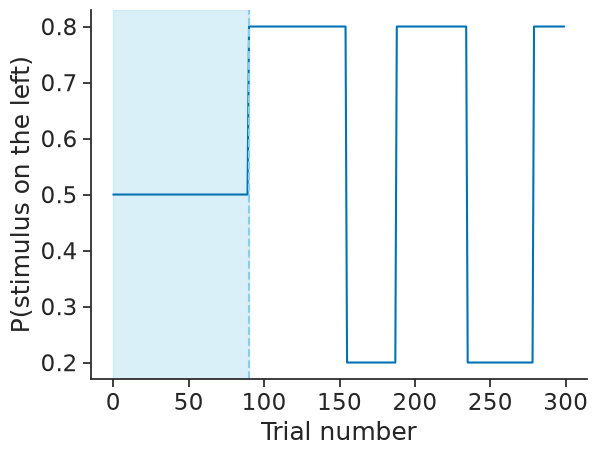

In [7]:
tutorial_utils.plot_proba_left(trials)

The probability of a stimulus appearing on the left is 50% for the first 90 trials and then shifts, biasing toward one side.

We will restrict the analysis to the first 90 trials of each session to match the work of Ashwood et al. (2022) <span id="cite1d"></span><a href="#ref1d">[1d]</a>. In this segment, the stimulus appears on the left and right with equal probability (0.5/0.5), so choices should be driven primarily by sensory evidence rather than learned expectations about stimulus probability. Following that work, we apply three restrictions:

1. Only keep sessions in which the animal went through the entire training criteria (i.e. sessions that contain 0.2, 0.5 and 0.8 probability blocks).
2. Within those sessions, select the 50-50 blocks.
3. Keep the blocks with fewer than 10 violations, where a violation is a trial in which the animal made no choice (`choice == 0`).

We apply all three restrictions with a single helper function, `select_sessions`. We pass it the trials DataFrame, the maximum number of violations to allow, and the value used to code a violation.

In [8]:
# Invalid choice marker: choice == 0 means the mouse made no choice
viol_val = 0

df_trials, valid_sessions = tutorial_utils.select_sessions(
    trials,
    max_violations=10,
    violation_value=viol_val,
)

print(f"# of sessions before restrictions {trials['session'].nunique()}")
print(f"# of sessions after restrictions {df_trials['session'].nunique()}")

# of sessions before restrictions 73
# of sessions after restrictions 56


`select_sessions` returns `df_trials`, the trials of the valid sessions restricted to the 50-50 block, and `valid_sessions`, the list of the identifiers of the valid sessions.

## 02. Building the design matrix

:::{admonition} What do we want to do in this subsection?
:class: attention

1. Preprocess and explain the predictors we will use to build our design matrix
2. Present the basis objects we need
3. Build our design matrix, which we will use as input for the GLM-HMM
:::

We are interested in building a design matrix with three predictors: previous choice, win-stay lose-shift (WSLS) and signed contrast.

### Select valid trials

First we take a subset of all trials, keeping only the valid trials (those in which the animal made a choice). `df_trials['choice'].values != viol_val` creates a boolean mask that is `True` for valid trials and `False` for violations, and `np.flatnonzero` returns the indices where it is `True`. These indices let us remove violation trials from every variable while keeping the remaining trials aligned.

In [9]:
# Boolean mask (valid: True; invalid: False) and its indices
valid_choices_bool = df_trials['choice'].values != viol_val
valid_choices_idx = np.flatnonzero(valid_choices_bool)

# Select all the values we need for the design matrix, keeping only valid trials
choices = df_trials['choice'].values[valid_choices_idx]
stim_left = df_trials['contrastLeft'].values[valid_choices_idx]
stim_right = df_trials['contrastRight'].values[valid_choices_idx]
rewards = df_trials['feedbackType'].values[valid_choices_idx]

We will build the design matrix using the NeMoS basis module `nmo.basis`, which makes the process much easier. A basis is a collection of functions that, when combined, can represent more complex relationships. NeMoS has many different basis functions, but here we are interested in two: `HistoryConv` and `IdentityEval`.

### Predictor 1: previous choice

:::{div} predictor-table

| Input | Definition | Interpretation |
|---|---|---|
| Previous choice <br> <img src="../assets/previous_choice.svg" alt="two trial frames: the previous trial holds the mouse's wheel turn, the current trial is empty" width="110"> | $\text{Previous choice}_t = c_{t-1}$ <br> with $c_t \in \{-1, +1\}$ | Direct lagged choice predictor, capturing serial dependence in decisions. |

:::

Previous choice is a lagged version of current choice, and it reflects serial dependence on decisions. For every time point, the predictor is the immediate previous choice taken. To create it, we can use the `HistoryConv` basis.

`HistoryConv` includes the past values of a sample as predictors (raw history). You choose how far back to go; here we only need one trial in the past (`window_size=1`).

In [10]:
# Prev history with history of 1
prev_choice_basis = nmo.basis.HistoryConv(1)

We can make a quick example to show what happens if we use `compute_features` with a short list.

In [11]:
# Example
prev_choice_basis.compute_features([1, 2, 3, 4])

Array([[nan],
       [ 1.],
       [ 2.],
       [ 3.]], dtype=float64)

We get a lagged list. Notice that the first element is a `NaN`: a history feature is defined using past trials, and since there is no past trial for the first trial, the feature is undefined and NeMoS fills it with a `NaN`.

### Predictor 2: WSLS

:::{div} predictor-table

| Input | Definition | Interpretation |
|---|---|---|
| Win-stay lose-shift <br> <img src="../assets/win_stay_lose_shift.svg" alt="after a reward the mouse repeats its wheel turn; after no reward it makes the opposite turn" width="180"> | $\text{WSLS}_t = c_{t-1} \cdot r_{t-1}$ <br> with $c_t, r_t \in \{-1, +1\}$ | Interaction of past choice and outcome: repeat a rewarded choice, switch away from an unrewarded one. |

:::

The four combinations of previous choice and previous outcome give:

| $c_{t-1}$ | $r_{t-1}$ | $\text{WSLS}_t$ | Behavior |
|---|---|---|---|
| $-1$ (right) | $+1$ (win) | $(-1)(+1) = -1$ | stay right |
| $-1$ (right) | $-1$ (lose) | $(-1)(-1) = +1$ | shift to left |
| $+1$ (left) | $+1$ (win) | $(+1)(+1) = +1$ | stay left |
| $+1$ (left) | $-1$ (lose) | $(+1)(-1) = -1$ | shift to right |

Win-stay lose-shift reflects the interaction between past choice and outcome: $WSLS_t = c_{t-1} \cdot r_{t-1}$. If a choice was rewarded on the previous trial, the predictor signals to "stay" (repeat that choice); if it was not rewarded, it signals to "switch" to the other alternative.

To capture an interaction between variables, we can use a [multiplicative basis object](../background/basis/plot_02_ND_basis_function.md), which in this case performs an element-wise multiplication. We create a lagged reward basis and multiply it with the lagged choice basis.

In [12]:
# Create lagged reward basis
prev_reward_basis = nmo.basis.HistoryConv(1)

# Multiply lagged reward basis with the lagged choice basis
wsls_basis = prev_choice_basis * prev_reward_basis

# Print: the product is still a basis
print(wsls_basis)

'(HistoryConv * HistoryConv_1)': MultiplicativeBasis(
    basis1=HistoryConv(window_size=1),
    basis2='HistoryConv_1': HistoryConv(window_size=1),
)


We can see what this does with an example.

In [13]:
choices_example = np.array([1, 0, 1, 0])
rewards_example = np.array([1, 2, 3, 4])

wsls_basis.compute_features(choices_example, rewards_example)

Array([[nan],
       [ 1.],
       [ 0.],
       [ 3.]], dtype=float64)

The result is an element-wise multiplication, shifted by one. The first element is $1 \times 1 = 1$, the second is $2 \times 0 = 0$, and so on. The shift happens for the same reason as the previous-choice predictor: NeMoS applies the computation only where it is well-defined, and pads with `NaN` where it is not.

### Predictor 3: stimulus contrast

:::{div} predictor-table

| Input | Definition | Interpretation |
|---|---|---|
| Signed contrast <br> <img src="../assets/screen_grating.svg" alt="stimulus grating" width="80"> | $\text{signed contrast} = \text{contrast}_\text{left} - \text{contrast}_\text{right}$ <br> with $\text{contrast}_\text{left}, \text{contrast}_\text{right} \in S$ <br> where $S = \{0, 0.0625, 0.125, 0.25, 1\}$ | Encodes sensory evidence in 1D; magnitude reflects strength, sign encodes direction. <br> $> 0$: left-favoring evidence <br> $< 0$: right-favoring evidence <br> $= 0$: no directional evidence |

:::

The signed contrast encodes sensory evidence in 1D. Its magnitude reflects the strength of evidence and its sign encodes direction. To build it, we replace `NaN` contrast values with `0` (a stimulus not being shown on one side is equivalent to a `0`-contrast stimulus on that side) and compute the difference between the left and right contrasts.

In [14]:
# Replace nans with 0s
stim_left = np.nan_to_num(stim_left, nan=0)
stim_right = np.nan_to_num(stim_right, nan=0)

# Compute the signed contrast
signed_contrast = stim_left - stim_right

# Print the signed contrast for the first valid session
select_session = df_trials['session'].values[valid_choices_idx] == valid_sessions[0]
print(signed_contrast[select_session])

[ 0.125   0.25   -1.     -1.     -0.25    0.25    0.      1.      0.25
  1.     -0.0625 -0.0625 -0.25   -1.     -0.25    0.      0.25   -1.
 -0.25    0.25    0.125   0.0625 -1.      0.125   0.     -1.      0.25
  0.25   -1.     -0.25    1.      1.     -1.      0.      0.0625 -0.25
  0.     -1.     -0.25   -1.      1.      0.125   0.0625 -0.0625  0.0625
 -0.25   -1.      1.     -0.0625  0.125   1.      1.     -0.25    0.125
  0.0625 -1.     -0.25    0.125   0.125   0.25    0.     -0.25    0.125
  0.0625 -0.125   1.     -0.125  -1.      1.      0.125   0.25   -0.25
  0.0625  0.125   0.     -0.0625 -0.0625 -0.125   0.125  -0.125  -0.0625
 -1.      0.25    1.      0.125   0.0625  1.     -0.25    0.      0.25  ]


We want to keep this predictor as it is, but we also need it as a NeMoS basis object so we can combine it with the others. For that, we use the `IdentityEval` basis, which uses the samples themselves as predictors. This may seem pointless, but it lets us wrap the signed contrast as a NeMoS object and combine it into a single additive basis.

In [15]:
# Identity basis for stimuli
stimuli_basis = nmo.basis.IdentityEval()

In [16]:
# Example: we get the same list back, now as a NeMoS basis object
stimuli_basis.compute_features([1, 2, 3, 4])

Array([[1.],
       [2.],
       [3.],
       [4.]], dtype=float64)

### Combining features and computing them

Now that we have all our bases, we can combine them into an additive basis and apply the transformation to the input data using `compute_features`. This method is a high-level interface for transforming input data with the basis functions.

In [17]:
# Create an additive basis using our three components:
# stimuli, wsls & previous choice
basis_object = (stimuli_basis + wsls_basis + prev_choice_basis)
print(basis_object)

'((IdentityEval + (HistoryConv * HistoryConv_1)) + HistoryConv_2)': AdditiveBasis(
    basis1='(IdentityEval + (HistoryConv * HistoryConv_1))': AdditiveBasis(
        basis1=IdentityEval(),
        basis2='(HistoryConv * HistoryConv_1)': MultiplicativeBasis(
            basis1=HistoryConv(window_size=1),
            basis2='HistoryConv_1': HistoryConv(window_size=1),
        ),
    ),
    basis2='HistoryConv_2': HistoryConv(window_size=1),
)


Even though we need just a few lines of code, there is a lot going on. Here's a breakdown:
1. We create an additive basis `basis_object` with `stimuli_basis`, `wsls_basis` and `prev_choice_basis`.
2. `wsls_basis` is a multiplicative basis that takes two inputs.
3. We compute the features for our `basis_object` using `compute_features`. Since the bases in our composite basis take a total of 4 inputs (`stimuli_basis` takes 1 input, `wsls_basis` takes 2 inputs and `prev_choice_basis` takes 1 input), we need to pass 4 inputs to `compute_features`, in the order in which they will be processed.

In [18]:
# Compute features
X_unnormalized = basis_object.compute_features(
    # input of stimuli_basis
    signed_contrast,
    # 1st input of wsls_basis
    choices,
    # 2nd input of wsls_basis
    rewards,
    # input of prev_choice_basis
    choices,
)

print(X_unnormalized[10:15])

[[ 0.25   -1.     -1.    ]
 [-0.0625  1.      1.    ]
 [-0.125  -1.      1.    ]
 [-0.125  -1.     -1.    ]
 [ 0.25   -1.      1.    ]]


And that's it! We have our unnormalized design matrix with signed contrast, win-stay lose-shift and previous choice as its three columns. As a last step, we normalize the signed-contrast predictor.

In [19]:
from scipy.stats import zscore

# Copy the array (we'll need the un-normalized later)
X = np.copy(X_unnormalized)

# Apply z-scoring to the signed-contrast column
X[:, 0] = zscore(X[:, 0])
print(X[10:15])

[[ 0.51278912 -1.         -1.        ]
 [-0.12756201  1.          1.        ]
 [-0.25563224 -1.          1.        ]
 [-0.25563224 -1.         -1.        ]
 [ 0.51278912 -1.          1.        ]]


```{admonition} Why do we normalize our stimuli predictor?
:class: question dropdown

When fitting a GLM-HMM, we fit a separate weight for each feature. If the features are on different numerical scales for reasons unrelated to the actual influence of each predictor, the weights become incomparable. Here we have three predictors:
- (1) Previous choice and (2) WSLS are always exactly −1 or +1. Their values are discrete and bounded, and they already share the same scale.
- (3) Stimulus contrast is continuous. While it can reach −1 or +1 (full contrast), this value rarely occurs.

Because the stimulus contrast values are typically much smaller in magnitude than ±1, the model would compensate by assigning a larger weight simply because its values are numerically smaller. In practice, this is an artifact of scale that does not reflect the true influence of the predictor.

By normalizing, we rescale the predictor to have mean 0 and standard deviation 1. Previous choice and WSLS are already on a unit scale by construction — their values are symmetric around zero and their spread is naturally 1. This is why we only normalize signed contrast.
```

Now we can visualize the design matrix that will be passed to the GLM. Each row corresponds to a trial, and each column corresponds to one predictor: signed contrast, WSLS, and previous choice — the order of the additive basis, rather than the order in which we introduced the predictors above. The color indicates the value of the predictor on each trial. For a given latent state, the model learns a weight for each predictor; these weights are combined with the design matrix to compute a linear score $X\beta$, which is passed through a sigmoid to obtain the probability of choosing left, and finally a Bernoulli observation model generates the choice.

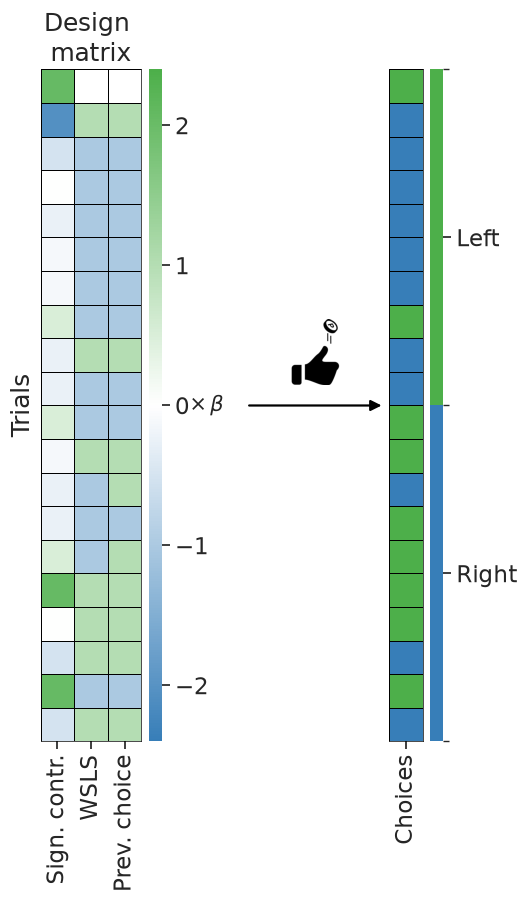

In [20]:
# Plot a heatmap showing the model design
tutorial_utils.plot_design_matrix(X, choices);

## 03. Model fitting

:::{admonition} What do we want to do in this subsection?
:class: attention

1. Convert choices so we can model them with a Bernoulli GLM-HMM
2. Build a vector containing session starts to use in fitting
3. Initialize our `GLMHMM` object and fit our model
:::

### Converting choices

We are going to fit a Bernoulli GLM-HMM to model binary choices. For a Bernoulli GLM-HMM, observations must take values of 0 or 1. In the current dataset, choices are encoded as `1` (left) and `-1` (right), so we remap right choices from `-1` to `0`.

In [21]:
choices[choices == -1] = 0
choices

array([1, 0, 0, ..., 0, 0, 0], shape=(5040,))

### Creating session boundaries

Importantly, we don't fit all the trials as one continuous block. The data come as separate sessions that the mouse completed over multiple days, and we fit the model on all of them together. For our model to be accurate, we need to tell it where the session boundaries are: we don't want it to treat all sessions as if they were one.

We can pass the session boundaries in different ways. If we are using NumPy arrays, we can pass a boolean array indicating `True` at the beginning of each session, or an array with the indices of the session changes. If we were using pynapple, the session boundaries would be inherited from the pynapple objects themselves.

We will build a boolean array to indicate the session changes. First, we create a session array aligned with our valid trials.

In [22]:
# Create a session array aligned with the valid trials
session = df_trials['session'].values[valid_choices_idx]

# Trials where the session id differs from the previous trial
session_changes = session[1:] != session[:-1]

Comparing `session[1:]` (every trial but the first) with `session[:-1]` (every trial but the last) yields a boolean array that is `True` wherever a trial's session id differs from the previous trial's — that is, exactly at the session boundaries. This comparison has two issues: it is shifted by one relative to the trials, and it leaves out the very first trial, which is itself the start of a session. We solve both at once by prepending a `True` to the array.

In [23]:
# The first trial is always a session start, and this also
# corrects the one-position shift from the comparison above
session_starts = np.concatenate(([True], session_changes))

We also want to restart our design matrix predictors win stay lose shift and previous choice at every session start, because there really is not a strategy considering a previous choice at the very beginning of each session.

In [24]:
X[session_starts, 1:3] = np.nan
X[session_starts][:5]

array([[ 2.04963184e+00,             nan,             nan],
       [ 5.08215184e-04,             nan,             nan],
       [-2.04861541e+00,             nan,             nan],
       [-2.04861541e+00,             nan,             nan],
       [-5.11772690e-01,             nan,             nan]])

```{admonition} How would this be different if we were using pynapple objects?
:class: note dropdown

What `session_starts` accepts depends on the type of `X` and `y`.

**NumPy inputs** (what we use here). There is no time axis to map onto, so boundaries
are given as sample positions:
- a boolean (or 0/1 integer) array of shape ``(n_samples,)`` marking session starts —
  the form we build here, or
- an integer array of shape ``(n_sessions,)`` giving the indices where sessions start.

With `session_starts=None`, the whole input is treated as a single session.

**Pynapple inputs.** If `X` or `y` is a `Tsd`/`TsdFrame`, you can leave
`session_starts=None` and the epochs of the object's `time_support` become the sessions
— one epoch, one session. (A time series built without an explicit `time_support` has a
single epoch, hence a single session; multiple epochs come from e.g. `restrict`.) You
can also pass an `IntervalSet`, which takes precedence over the object's own
`time_support`. Only its start times are used: it marks where sessions begin, it does
not drop samples. Restrict the data beforehand if you want samples excluded.

The array forms also take precedence over `time_support`. An `IntervalSet`, on the other
hand, requires a pynapple `X` or `y` — mapping epoch start times to sample positions
needs the timestamps — and raises a `TypeError` with NumPy inputs.
```

### Initialize and fit the GLM-HMM

Let's initialize the `GLMHMM` object. The only required parameter is the number of states. Ashwood et al. (2022) <span id="cite1e"></span><a href="#ref1e">[1e]</a> found that most mice used 3 decision-making states when performing this task, so we will initialize our `GLMHMM` object with 3 states. We also set `regularizer="Ridge"` to penalize large weights, and a seed for our initial parameters.

```{admonition} GLM-HMM observation models
:class: note

The default observation model for the GLM-HMM is Bernoulli, but Categorical (Multinomial), Poisson, Gamma, Negative Binomial and Gaussian observation models are also available. If you want, you can set a different observation model and personalize the inverse link function. However, keep in mind that convexity is not guaranteed for all likelihood functions.

For more information, refer to Escola et al. (2011) <span id="cite4"></span><a href="#ref4">[4]</a>.
```
____
If you don't set up any initialization settings, you would use the NeMoS defaults:
- ``"glm_params_init"``: ``"random"`` - small random coefficients, mean-rate intercept
- ``"scale_init"``: ``"constant"`` - scale initialized to 1.0
- ``"initial_proba_init"``: ``"uniform"`` - equal probability for all states
- ``"transition_proba_init"``: ``"sticky"`` - high self-transition probability (0.95)

```{admonition} Importance of initial parameters in GLM-HMMs
:class: question dropdown

The likelihood of a GLM-HMM is non-convex, so the EM algorithm used to fit it can converge to different local optima depending on the starting parameters. NeMoS initializes the model for you: by default, the per-state intercepts are set to match the empirical choice probability, and the GLM coefficients are drawn from a Gaussian centered at zero with a small standard deviation. The seed argument controls this random draw, so in practice you should refit the model with several seeds and keep the solution with the highest log-likelihood.
```

In [25]:
n_states = 3
seed = jax.random.PRNGKey(12)

model = nmo.glm_hmm.GLMHMM(
    n_states=n_states,
    regularizer="Ridge",
    # change this to try multiple init
    seed=seed,
)

model

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...x7f70f2cf9a80>
,regularizer,Ridge()
,solver_name,'LBFGS'
,solver_kwargs,{}
,seed,"Array([ 0, 12], dtype=uint32)"
,hmm_initialization_funcs,"{'initial_proba_init': <function uni...x7f70f2f3bc40>, 'initial_proba_init_custom': False, 'initial_proba_init_kwargs': {}, 'transition_proba_init': <function sti...x7f70f2f3b880>, ...}"
,model_initialization_funcs,"{'glm_params_init': <function ran...x7f70f2ff4f40>, 'glm_params_init_custom': False, 'glm_params_init_kwargs': {}, 'scale_init': <function con...x7f70f2ff54e0>, ...}"
,regularizer_strength,1.0
,dirichlet_initial_proba,None


Once we created our object, we can fit our model. The fit function takes three mandatory arguments: the design matrix `X`, the `choices`, and  `session_starts`, the session indicator we built above.

In [26]:
model.fit(X, choices, session_starts=session_starts)

,n_states,3
,observation_model,BernoulliObservations()
,inverse_link_function,<function log...x7f70f2cf9a80>
,regularizer,Ridge()
,solver_name,'LBFGS'
,solver_kwargs,{}
,seed,"Array([ 0, 12], dtype=uint32)"
,hmm_initialization_funcs,"{'initial_proba_init': <function uni...x7f70f2f3bc40>, 'initial_proba_init_custom': False, 'initial_proba_init_kwargs': {}, 'transition_proba_init': <function sti...x7f70f2f3b880>, ...}"
,model_initialization_funcs,"{'glm_params_init': <function ran...x7f70f2ff4f40>, 'glm_params_init_custom': False, 'glm_params_init_kwargs': {}, 'scale_init': <function con...x7f70f2ff54e0>, ...}"
,regularizer_strength,1.0
,dirichlet_initial_proba,None


That's all it takes!

## 04. Interpreting the results

:::{admonition} What do we want to do in this subsection?
:class: attention

1. Inspect the output of the model
2. Interpret the GLM weights and transition matrix
3. Use NeMoS built-in functions to visualize and interpret the temporal structure of state transitions
:::

### How to visualize the fitted parameters

Latent state labels are arbitrary: what the model labels as state 1 could just as well be labeled state 2 or 3. Before interpreting anything, we relabel the states so that our labels match the reference paper: engaged state first, followed by biased-left and biased-right.

In [27]:
model = tutorial_utils.relabel(model)

After fitting, the GLM coefficients and intercept, and the HMM initial and transition probabilities are stored in the following attributes:

- `model.coef_`
- `model.intercept_`
- `model.initial_prob_`
- `model.transition_prob_`

Let's print them.

In [28]:
print("GLM parameters\n==============")
print(f"glm weights:\n{model.coef_}\n")
print(f"intercept:\n{model.intercept_}")

print("\n\nHMM parameters\n==============")
print(f"transition matrix \n {model.transition_prob_}\n")
print(f"initial probabilities \n {model.initial_prob_}")

GLM parameters
glm weights:
[[ 6.04106875  1.52092913  1.58963141]
 [ 0.09683148  0.27445887  0.32918376]
 [ 0.1265654  -0.29092423  0.31762995]]

intercept:
[ 0.01709546  2.68633244 -2.31471026]


HMM parameters
transition matrix 
 [[0.98276852 0.01040598 0.00682551]
 [0.03783389 0.95245121 0.0097149 ]
 [0.03919955 0.00377866 0.9570218 ]]

initial probabilities 
 [0.64440975 0.14373909 0.21185115]


Let's see what type of information we can gather.

### Interpreting the GLM weights

We can plot the GLM weights obtained for our 3-state model.

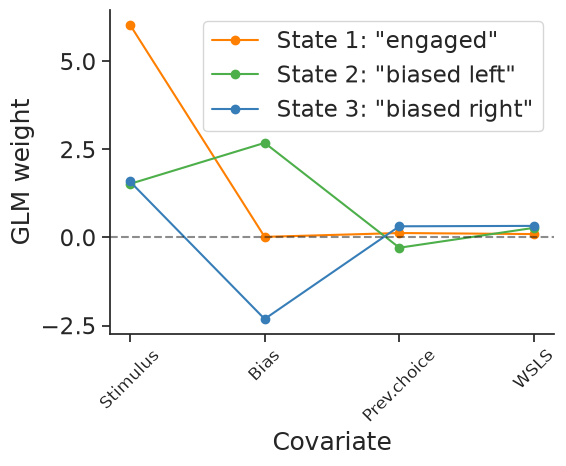

In [29]:
tutorial_utils.plot_glm_weights(model);

State 1 ("engaged") has a large positive weight on the stimulus and weights close to zero on all other predictors, suggesting the animal is primarily driven by sensory information in this state. States 2 ("biased left") and 3 ("biased right") show large bias weights of opposite sign (positive for state 2 and negative for state 3), which indicates a systematic tendency to choose left or right regardless of the stimulus. Since the sign of our predictors indicates the side of evidence (>0: left; <0: right) and their magnitude indicates its strength, State 2 coefficients suggest a bias toward leftward choice while State 3 coefficients suggest a bias toward rightward choice. All three states have very low weights on previous choice and WSLS, with State 1 showing the smallest of them.

As a reminder, the task required indicating whether the stimulus was on the right or the left of the screen, using the stimulus contrast. The optimal strategy is therefore to rely on stimulus contrast as much as possible, rather than on bias, previous choice, or WSLS.

### Interpreting the transition matrix

We can also see the fitted transition matrix for our three-state model. This describes the transition probabilities among the different states, each corresponding to a different decision-making strategy. Large entries on the diagonal indicate a high probability of remaining in the same state for multiple trials in a row.

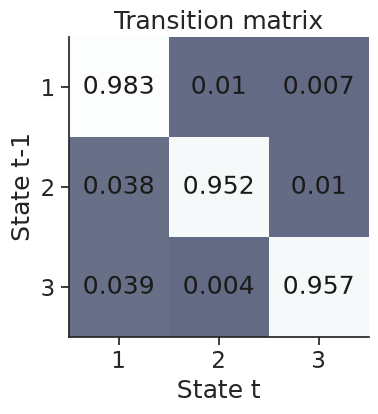

In [30]:
tutorial_utils.plot_transition_matrix(model);

The diagonal entries are all high, which indicates that each state is highly self-persistent: once the animal enters a state, it is very likely to remain in that state on the next trial. Off-diagonal transitions are rare, meaning switches between states occur infrequently.

### Using `smooth_proba` to see and interpret posterior state probabilities

To better understand the temporal structure of decision-making behavior, we can compute the probability of being in each state at each trial, conditioned on the entire observed sequence. For this, we use `smooth_proba`. This method uses the forward-backward algorithm to incorporate information from past and future observations. It answers the question: "Given all observations, what is the probability that the system was in state $k$ at time $t$?"

`smooth_proba` takes a design matrix `X` and the observed choices `y`; when the inputs are NumPy arrays we also pass `session_starts` (with pynapple inputs the session boundaries are inherited automatically). The output is either a `TsdFrame` or an array of posterior probabilities of shape `(n_time_points, n_states)`. Each row sums to 1 and represents the probability distribution over states at that time point.

In [31]:
# Compute smooth_proba
posteriors = model.smooth_proba(
    X,
    choices,
    session_starts=session_starts
)

print(f"First five posteriors \n{posteriors[:5]} \n")

# Each (non-nan) row sums to 1
valid_post = ~np.isnan(posteriors).any(axis=1)

print(
    f"Each row sums to 1: {np.allclose(posteriors[valid_post].sum(axis=1), 1)}"
)

First five posteriors 
[[           nan            nan            nan]
 [8.60153809e-01 5.71722942e-03 1.34128962e-01]
 [8.73060868e-01 7.72018592e-04 1.26167113e-01]
 [8.82386827e-01 1.33654834e-04 1.17479518e-01]
 [9.00539046e-01 6.64519007e-05 9.93945022e-02]] 

Each row sums to 1: True


The first trial of each session is `NaN`: the posterior depends on the transition from the previous trial's state, which doesn't exist at a session start. Hence we mask out the NaNs before checking that the rows sum to one.

Let's now use the utility function to plot the three sessions shown in Fig. 3a of <span id="cite1f"></span><a href="#ref1f">[1f]</a>.

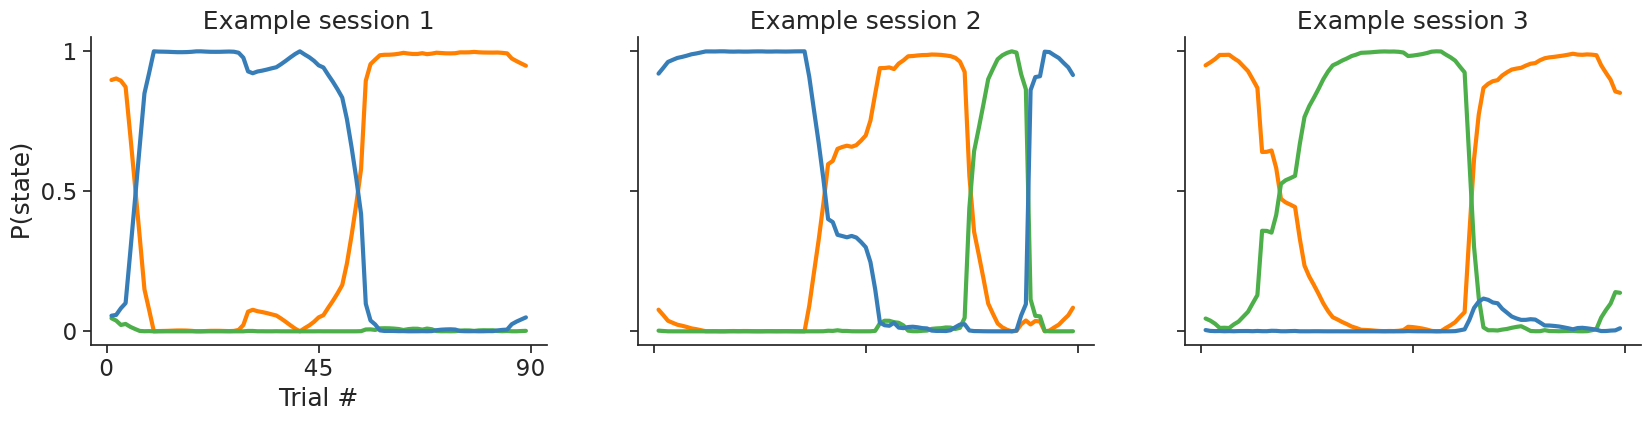

In [32]:
tutorial_utils.plot_posteriors(posteriors, session);

In these sessions, the posterior over latent states can be tracked at each trial, revealing strong confidence in state assignments and extended periods where a single state persists across consecutive trials. This pattern is inconsistent with the short, transient lapses assumed in lapse-based models.

### Understanding mouse behavior in different states

We can also quantify state occupancies (i.e. what proportion of the trials a given animal spent in each state) and accuracies (i.e. how often it chose the correct side) per state. For this, we need the inferred sequence of states, and there are (at least) two ways to obtain it: using `decode_state` or using `smooth_proba`.

#### Using `decode_state`

This method finds the single most likely sequence of hidden states that best explains the observed data: the state sequence that maximizes the joint probability of states and observations. It does so using the [Viterbi algorithm](https://en.wikipedia.org/wiki/Viterbi_algorithm).

It takes two mandatory arguments: a matrix of predictors `X` of shape `(n_timepoints, n_features)` and a `np.array` or `nap.Tsd` of observations of shape `(n_time_points,)`(plus `session_starts` when the inputs are NumPy arrays). We can also edit `state_format`, the format of the returned states: either one-hot encoding or an array of shape `(n_time_points,)` containing the decoded state at each timepoint.

In [33]:
# Get output of Viterbi in one-hot encoding
decoded_states = model.decode_state(
    X,
    choices,
    session_starts=session_starts,
    state_format="one-hot"
)
print(f"{decoded_states} \n")

[[nan nan nan]
 [ 1.  0.  0.]
 [ 1.  0.  0.]
 ...
 [ 0.  0.  1.]
 [ 0.  0.  1.]
 [ 0.  0.  1.]] 



From this we can compute the fractional occupancy, while correctly filtering out the NaNs. Because the states are one-hot encoded, summing each column counts how many trials were assigned to each state; `np.nansum` ignores the NaNs during this count, and we normalize by the number of valid trials.

In [34]:
# Rows without any NaN have a valid state assignment
valid_decoded = np.all(~np.isnan(decoded_states), axis=1)

# Fraction of occupancy per state
frac_occupancy_viterbi = np.nansum(decoded_states, axis=0) / valid_decoded.sum()
print(f"Fraction of occupancy {frac_occupancy_viterbi} \n")

Fraction of occupancy [0.72552167 0.13743981 0.13703852] 



Now we can compute the mouse's overall accuracy. We first mask out the 0-contrast stimuli (because there is no correct answer in that case), and use `feedbackType` to identify the correct choices (`rewards == 1`).

In [35]:
# Mask out the 0 contrast stimuli
non_zero_contrast = signed_contrast != 0

# A correct choice is one that was rewarded
correct_choices = rewards == 1

# Compute the total accuracy applying the mask
total_accuracy = np.mean(correct_choices[non_zero_contrast])

# Store in an array of dim 4 (overall + one per state)
accuracies_to_plot_viterbi = np.zeros(4)
accuracies_to_plot_viterbi[0] = total_accuracy

Then we can use the output of `decode_state` to segment the trials into the estimated states and compute the accuracy within each state; that is, whether the animal performs better or worse depending on the state it is in.

In [36]:
accuracy_per_state = np.zeros(n_states)
for s in range(n_states):
    in_state = (decoded_states[:, s] == 1)
    accuracy_per_state[s] = np.mean(correct_choices[in_state & non_zero_contrast])

accuracies_to_plot_viterbi[1:] = accuracy_per_state
print(f"Overall and per-state accuracy: {accuracies_to_plot_viterbi}")

Overall and per-state accuracy: [0.80355936 0.86485643 0.6422629  0.62671233]


And we can plot this.

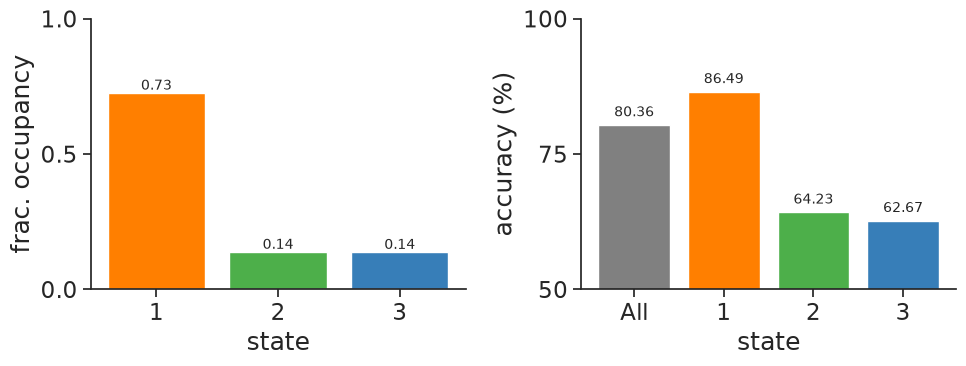

In [37]:
tutorial_utils.plot_accuracy_and_occupancy(
    frac_occupancy_viterbi,
    accuracies_to_plot_viterbi
);

According to state occupancy derived with the Viterbi algorithm, this mouse spent the majority of the trials (73%) in the engaged state and a smaller portion (27%) in the other two states. Even though this mouse had an overall accuracy of 80.36%, it achieved a higher accuracy of 86.76% in the "engaged" state compared to 64.37% and 61.69% in the "biased left" and "biased right" states, respectively. This makes sense, considering that the information needed to perform the task well was the signed contrast.

#### Using `smooth_proba`

Now we compute the same quantities using `smooth_proba`. In contrast to `decode_state`, which outputs the globally optimal state sequence, `smooth_proba` outputs probabilistic posteriors. We can therefore compute the posterior probability of each state at every trial, assign each valid trial to its most likely state, and count the fraction of trials assigned to each state.

The process is very similar to the previous section; the difference is in how we assign trials to a state. We start with the fraction of occupancy.

In [38]:
# Most likely state per trial, ignoring session-start NaNs
valid_post = ~np.isnan(posteriors).any(axis=1)
states_max_posterior = np.argmax(posteriors[valid_post], axis=1)

# Count and normalize over valid trials
occupancy_per_state = np.bincount(states_max_posterior, minlength=n_states)
frac_occupancy_smooth_proba = occupancy_per_state / valid_post.sum()
print(f"Fraction of occupancy {frac_occupancy_smooth_proba} \n")

Fraction of occupancy [0.69542536 0.15308989 0.15148475] 



With this segmentation, we can compute the accuracy in the exact same manner as in the previous section.

Overall and per-state accuracy: [0.80355936 0.87150293 0.64925373 0.63410853]


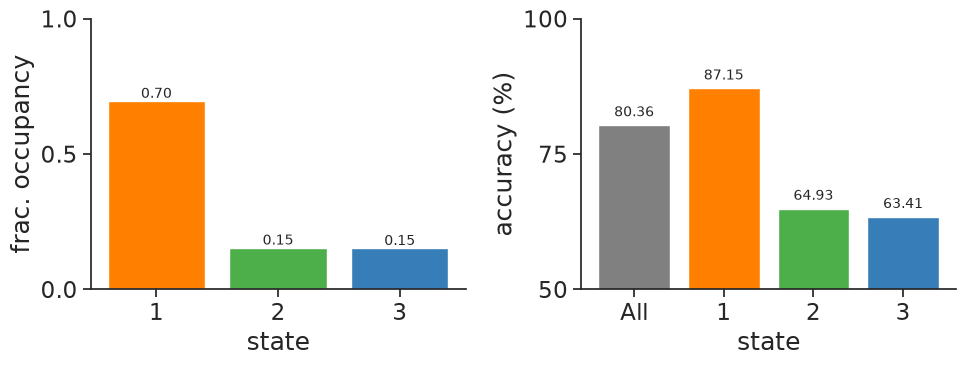

In [39]:
# Store in an array of dim 4; the overall accuracy is the same as for Viterbi
accuracies_to_plot_smooth_proba = np.zeros(4)
accuracies_to_plot_smooth_proba[0] = total_accuracy

accuracy_per_state = np.zeros(n_states)
for s in range(n_states):
    in_state = (states_max_posterior == s) & non_zero_contrast[valid_post]
    accuracy_per_state[s] = correct_choices[valid_post][in_state].mean()

accuracies_to_plot_smooth_proba[1:] = accuracy_per_state
print(f"Overall and per-state accuracy: {accuracies_to_plot_smooth_proba}")

tutorial_utils.plot_accuracy_and_occupancy(
    frac_occupancy_smooth_proba,
    accuracies_to_plot_smooth_proba
);

According to state occupancy derived by assigning each trial to its most likely state under the posterior, this mouse again spent the majority of the trials (69%) in the engaged state and a smaller portion (31%) in the other two states. As before, the overall accuracy is 80.36%, while the "engaged" state reaches 87.26% compared to 65.22% and 63.49% in the "biased left" and "biased right" states, respectively.

The results here differ slightly from the previous section because of the different algorithms used to segment the trials: Viterbi finds the most likely sequence of states as a whole, whereas this approach determines the most likely state on a trial-by-trial basis.

## Conclusion

In this notebook, we replicated some of the findings of Ashwood et al. (2022) using NeMoS, showing that mice alternate between discrete behavioral strategies during perceptual decision-making. Here is what we covered:

1. **Download and preprocessing of IBL data**: we showed how to obtain a dataset from the International Brain Laboratory using ONE, and how preprocess it to fit the model to it.
2. **Design matrix construction**: we transformed raw behavioral variables into three interpretable predictors (signed contrast (sensory evidence), previous choice (serial dependence), and WSLS (reward-modulated repetition)) using NeMoS basis objects and `compute_features`.
3. **Fitting across sessions**: fitting a 3-state GLM-HMM to trials across multiple sessions required just a few lines of code:

```python
model = nmo.glm_hmm.GLMHMM(n_states=3, regularizer="Ridge", seed=seed)
model.fit(X, choices, session_starts=session_starts)
```

4. **Interpretable parameters and linking states to behavior**: the GLM weights showed three distinct strategies - an engaged state driven by stimulus contrast, and two bias states favoring left or right regardless of evidence. The transition matrix showed that each strategy was stable across multiple consecutive trials. Also, `smooth_proba` and `decode_state` allowed us to track when each strategy was used and quantify its effect on performance.

## Additional resources
- [Bishop (2006) Chapter 13 "Sequential Data"](https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf): Specially section 13.2, "Hidden Markov Models", provides an overview of MLE for HMMs, the forward-backward algorithm and the Viterbi algorithm.
- [Zoe Ashwood's SSM tutorial on GLM-HMMs](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb): this educational notebook explains GLM-HMMs and fitting with MLE and MAP.
- [GLM-HMMs blogpost by Camila Ucheoma](https://anneurai.net/2024/01/26/a-glm-hmm-deep-dive/): this blogpost provides a summary of Ashwood et al. (2022) and a brief explanation of GLM-HMMs.

## References
<a id="ref1a"><a href="#cite1a">[1a]</a> <a id="ref1b"><a href="#cite1b">[1b]</a> <a id="ref1c"><a href="#cite1c">[1c]</a> <a id="ref1d"><a href="#cite1d">[1d]</a> <a id="ref1e"><a href="#cite1e">[1e]</a> <a id="ref1f"><a href="#cite1f">[1f]</a> [Ashwood, Z. C., Roy, N. A., Stone, I. R., Laboratory, I. B., Urai, A. E., Churchland, A. K., Pouget, A., & Pillow, J. W. (2022). Mice alternate between discrete strategies during perceptual decision-making. Nature Neuroscience, 25(2), 201–212.](https://doi.org/10.1038/s41593-021-01007-z)

<a id="ref2a"><a href="#cite2a">[2a]</a><a id="ref2b"> <a href="#cite2b">[2b]</a> [The International Brain Laboratory, Aguillon-Rodriguez, V., Angelaki, D., Bayer, H., Bonacchi, N., Carandini, M., Cazettes, F., Chapuis, G., Churchland, A. K., Dan, Y., Dewitt, E., Faulkner, M., Forrest, H., Haetzel, L., Häusser, M., Hofer, S. B., Hu, F., Khanal, A., Krasniak, C., … Zador, A. M. (2021). Standardized and reproducible measurement of decision-making in mice. eLife, 10, e63711.](https://doi.org/10.7554/eLife.63711)

<a id="ref3"><a href="#cite3">[3]</a> [Burgess, C. P., Lak, A., Steinmetz, N. A., Zatka-Haas, P., Bai Reddy, C., Jacobs, E. A. K., Linden, J. F., Paton, J. J., Ranson, A., Schröder, S., Soares, S., Wells, M. J., Wool, L. E., Harris, K. D., & Carandini, M. (2017). High-Yield Methods for Accurate Two-Alternative Visual Psychophysics in Head-Fixed Mice. Cell Reports, 20(10), 2513–2524.](https://doi.org/10.1016/j.celrep.2017.08.047)

<a id="ref4"><a href="#cite4">[4]</a> [Escola, S., Fontanini, A., Katz, D., & Paninski, L. (2011). Hidden Markov models for the stimulus-response relationships of multistate neural systems. Neural Computation, 23(5), 1071–1132.](https://doi.org/10.1162/NECO_a_00118)